In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load synthetic datasets
data_no_bc = pd.read_csv(r"C:\Users\prady\Downloads\Thesis_n\s\synthetic_data_no_blockchain_final_traceability.csv")
data_with_bc = pd.read_csv(r"C:\Users\prady\Downloads\Thesis_n\s\synthetic_data_with_blockchain_final_traceability.csv")

# Features and target
features = ['Lead_Time_days', 'Inventory_Accuracy', 'Supplier_Lead_Time_Variability_days',
            'Inventory_Turnover_Ratio', 'Customer_Satisfaction', 'Supplier_Relationship_Score',
            'Order_Fulfillment_Rate', 'Operational_Efficiency_Score', 'Transparency', 'Traceability']

X_no_bc = data_no_bc[features]
y_no_bc = data_no_bc['Supply_Chain_Risk']
X_with_bc = data_with_bc[features]
y_with_bc = data_with_bc['Supply_Chain_Risk']

# Normalize features
scaler = StandardScaler()
X_no_bc_scaled = scaler.fit_transform(X_no_bc)
X_with_bc_scaled = scaler.fit_transform(X_with_bc)

# Split data
X_train_no_bc, X_test_no_bc, y_train_no_bc, y_test_no_bc = train_test_split(X_no_bc_scaled, y_no_bc, test_size=0.2, random_state=42)
X_train_with_bc, X_test_with_bc, y_train_with_bc, y_test_with_bc = train_test_split(X_with_bc_scaled, y_with_bc, test_size=0.2, random_state=42)

# Define XGBoost models with increased regularization
model_no_bc = xgb.XGBRegressor(objective='reg:squarederror', max_depth=5, learning_rate=0.1, n_estimators=100, reg_lambda=5.0, random_state=42)
model_with_bc = xgb.XGBRegressor(objective='reg:squarederror', max_depth=5, learning_rate=0.1, n_estimators=100, reg_lambda=5.0, random_state=42)

# Train models
model_no_bc.fit(X_train_no_bc, y_train_no_bc)
model_with_bc.fit(X_train_with_bc, y_train_with_bc)

# Predict and evaluate
y_pred_no_bc = model_no_bc.predict(X_test_no_bc)
y_pred_with_bc = model_with_bc.predict(X_test_with_bc)

mse_no_bc = mean_squared_error(y_test_no_bc, y_pred_no_bc)
r2_no_bc = r2_score(y_test_no_bc, y_pred_no_bc)
mse_with_bc = mean_squared_error(y_test_with_bc, y_pred_with_bc)
r2_with_bc = r2_score(y_test_with_bc, y_pred_with_bc)

# Cross-validation
cv_scores_no_bc = cross_val_score(model_no_bc, X_no_bc_scaled, y_no_bc, cv=5, scoring='r2')
cv_scores_with_bc = cross_val_score(model_with_bc, X_with_bc_scaled, y_with_bc, cv=5, scoring='r2')

# Feature importance
importance_no_bc = model_no_bc.feature_importances_
importance_with_bc = model_with_bc.feature_importances_

# Print results
print("Non-Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(mse_no_bc, r2_no_bc, cv_scores_no_bc.mean(), cv_scores_no_bc.std() * 2))
print("Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(mse_with_bc, r2_with_bc, cv_scores_with_bc.mean(), cv_scores_with_bc.std() * 2))
print("\nFeature Importance (Non-Blockchain):CITATION Saberi2021 \l 16393")
for feature, importance in zip(features, importance_no_bc):
    print(f"{feature}: {importance:.6f}")
print("\nFeature Importance (Blockchain):")
for feature, importance in zip(features, importance_with_bc):
    print(f"{feature}: {importance:.6f}")

# Transform predicted Supply_Chain_Risk into Supply_Chain_Risk_Mitigation_Power
# Step 1: Invert the risk (since lower risk means better mitigation)
mitigation_power_no_bc = -y_pred_no_bc
mitigation_power_with_bc = -y_pred_with_bc

# Step 2: Normalize to 0-100 scale
all_mitigation_power = np.concatenate([mitigation_power_no_bc, mitigation_power_with_bc])
min_mitigation = all_mitigation_power.min()
max_mitigation = all_mitigation_power.max()
mitigation_power_no_bc_normalized = 100 * (mitigation_power_no_bc - min_mitigation) / (max_mitigation - min_mitigation)
mitigation_power_with_bc_normalized = 100 * (mitigation_power_with_bc - min_mitigation) / (max_mitigation - min_mitigation)

# Compare average predicted mitigation power
avg_mitigation_no_bc = mitigation_power_no_bc_normalized.mean()
avg_mitigation_with_bc = mitigation_power_with_bc_normalized.mean()
print("\nAverage Predicted Supply Chain Risk Mitigation Power (0-100 scale):")
print(f"Non-Blockchain: {avg_mitigation_no_bc:.6f}")
print(f"Blockchain: {avg_mitigation_with_bc:.6f}")
print(f"Difference (BC - Non-BC): {avg_mitigation_with_bc - avg_mitigation_no_bc:.6f}")

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
C:\Users\prady\AppData\Local\Temp\ipykernel_27240\233402850.py:59: SyntaxWarning: invalid escape sequence '\l'
  print("\nFeature Importance (Non-Blockchain):CITATION Saberi2021 \l 16393")


Non-Blockchain Model - MSE: 0.064771, R²: 0.697186, CV R² Mean: 0.695701 (+/- 0.043043)
Blockchain Model - MSE: 0.035927, R²: 0.864175, CV R² Mean: 0.857489 (+/- 0.017413)

Feature Importance (Non-Blockchain):CITATION Saberi2021 \l 16393
Lead_Time_days: 0.010523
Inventory_Accuracy: 0.011946
Supplier_Lead_Time_Variability_days: 0.016278
Inventory_Turnover_Ratio: 0.013337
Customer_Satisfaction: 0.013717
Supplier_Relationship_Score: 0.015798
Order_Fulfillment_Rate: 0.013077
Operational_Efficiency_Score: 0.013575
Transparency: 0.869180
Traceability: 0.022568

Feature Importance (Blockchain):
Lead_Time_days: 0.006927
Inventory_Accuracy: 0.007860
Supplier_Lead_Time_Variability_days: 0.009537
Inventory_Turnover_Ratio: 0.007569
Customer_Satisfaction: 0.009217
Supplier_Relationship_Score: 0.007286
Order_Fulfillment_Rate: 0.007316
Operational_Efficiency_Score: 0.008232
Transparency: 0.909752
Traceability: 0.026305

Average Predicted Supply Chain Risk Mitigation Power (0-100 scale):
Non-Blockchai

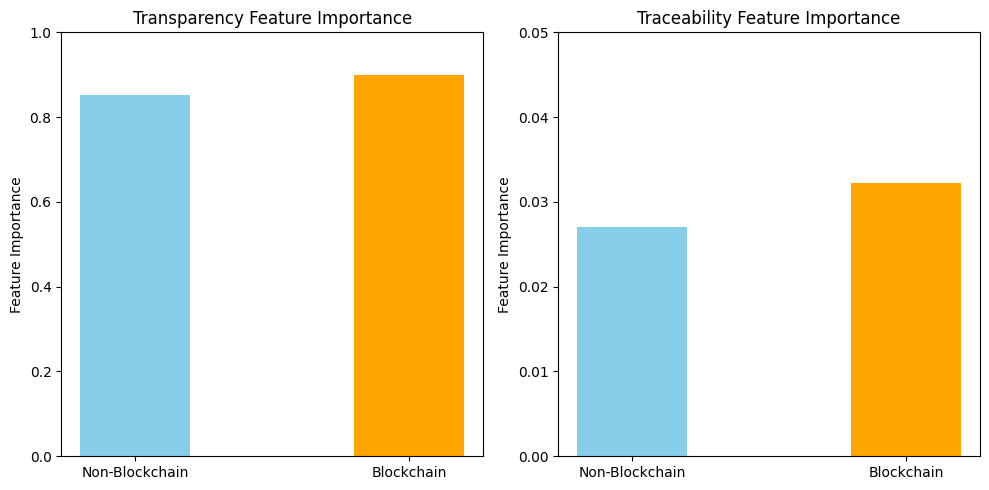

In [5]:
import matplotlib.pyplot as plt

# Data
features = ['Transparency', 'Traceability']
non_bc_importance = [0.851804, 0.027062]
bc_importance = [0.899541, 0.032259]

# Create two separate figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=False)

# Plot for Transparency
ax1.bar(['Non-Blockchain', 'Blockchain'], [non_bc_importance[0], bc_importance[0]], 
        color=['skyblue', 'orange'], width=0.4)
ax1.set_title('Transparency Feature Importance')
ax1.set_ylabel('Feature Importance')
ax1.set_ylim(0, 1.0)  # Adjust y-axis for Transparency (larger values)

# Plot for Traceability
ax2.bar(['Non-Blockchain', 'Blockchain'], [non_bc_importance[1], bc_importance[1]], 
        color=['skyblue', 'orange'], width=0.4)
ax2.set_title('Traceability Feature Importance')
ax2.set_ylabel('Feature Importance')
ax2.set_ylim(0, 0.05)  # Adjust y-axis for Traceability (smaller values)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plots
plt.show()

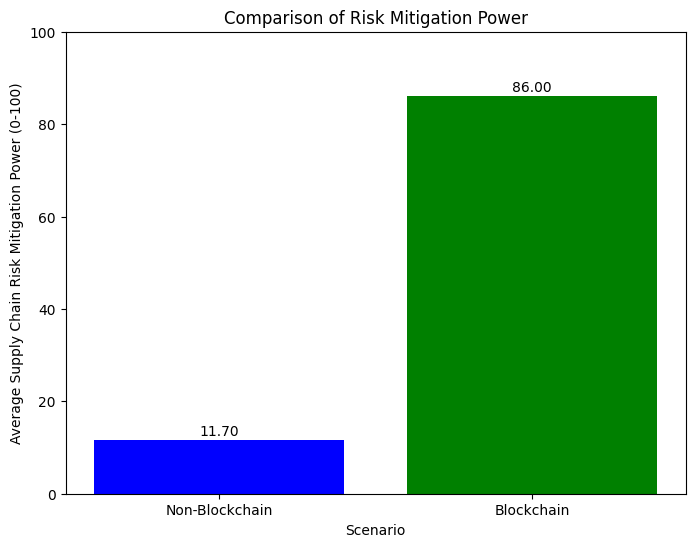

In [6]:
# Plot the results using canvas panel
plt.figure(figsize=(8, 6))
scenarios = ['Non-Blockchain', 'Blockchain']
mitigation_values = [avg_mitigation_no_bc, avg_mitigation_with_bc]
plt.bar(scenarios, mitigation_values, color=['blue', 'green'])
plt.xlabel('Scenario')
plt.ylabel('Average Supply Chain Risk Mitigation Power (0-100)')
plt.title('Comparison of Risk Mitigation Power')
plt.ylim(0, 100)  # Ensure the y-axis is 0-100
for i, v in enumerate(mitigation_values):
    plt.text(i, v + 1, f'{v:.2f}', ha='center')
plt.show()

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load synthetic datasets
data_no_bc = pd.read_csv(r"C:\Users\prady\Downloads\Thesis_n\s\synthetic_data_no_blockchain_final_traceability.csv")
data_with_bc = pd.read_csv(r"C:\Users\prady\Downloads\Thesis_n\s\synthetic_data_with_blockchain_final_traceability.csv")

# Features and target
features = ['Lead_Time_days', 'Inventory_Accuracy', 'Supplier_Lead_Time_Variability_days',
            'Inventory_Turnover_Ratio', 'Customer_Satisfaction', 'Supplier_Relationship_Score',
            'Order_Fulfillment_Rate', 'Operational_Efficiency_Score', 'Transparency', 'Traceability']

X_no_bc = data_no_bc[features]
y_no_bc = data_no_bc['Supply_Chain_Risk']
X_with_bc = data_with_bc[features]
y_with_bc = data_with_bc['Supply_Chain_Risk']

# Normalize features
scaler = StandardScaler()
X_no_bc_scaled = scaler.fit_transform(X_no_bc)
X_with_bc_scaled = scaler.fit_transform(X_with_bc)

# Split data
X_train_no_bc, X_test_no_bc, y_train_no_bc, y_test_no_bc = train_test_split(X_no_bc_scaled, y_no_bc, test_size=0.2, random_state=42)
X_train_with_bc, X_test_with_bc, y_train_with_bc, y_test_with_bc = train_test_split(X_with_bc_scaled, y_with_bc, test_size=0.2, random_state=42)

# Define models
# XGBoost
xgb_model_no_bc = xgb.XGBRegressor(objective='reg:squarederror', max_depth=5, learning_rate=0.1, n_estimators=100, reg_lambda=5.0, random_state=42)
xgb_model_with_bc = xgb.XGBRegressor(objective='reg:squarederror', max_depth=5, learning_rate=0.1, n_estimators=100, reg_lambda=5.0, random_state=42)

# Random Forest
rf_model_no_bc = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model_with_bc = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Train models
# XGBoost
xgb_model_no_bc.fit(X_train_no_bc, y_train_no_bc)
xgb_model_with_bc.fit(X_train_with_bc, y_train_with_bc)
# Random Forest
rf_model_no_bc.fit(X_train_no_bc, y_train_no_bc)
rf_model_with_bc.fit(X_train_with_bc, y_train_with_bc)

# Predict and evaluate
# XGBoost predictions
xgb_y_pred_no_bc = xgb_model_no_bc.predict(X_test_no_bc)
xgb_y_pred_with_bc = xgb_model_with_bc.predict(X_test_with_bc)
# Random Forest predictions
rf_y_pred_no_bc = rf_model_no_bc.predict(X_test_no_bc)
rf_y_pred_with_bc = rf_model_with_bc.predict(X_test_with_bc)

# Evaluate XGBoost
xgb_mse_no_bc = mean_squared_error(y_test_no_bc, xgb_y_pred_no_bc)
xgb_r2_no_bc = r2_score(y_test_no_bc, xgb_y_pred_no_bc)
xgb_mse_with_bc = mean_squared_error(y_test_with_bc, xgb_y_pred_with_bc)
xgb_r2_with_bc = r2_score(y_test_with_bc, xgb_y_pred_with_bc)

# Evaluate Random Forest
rf_mse_no_bc = mean_squared_error(y_test_no_bc, rf_y_pred_no_bc)
rf_r2_no_bc = r2_score(y_test_no_bc, rf_y_pred_no_bc)
rf_mse_with_bc = mean_squared_error(y_test_with_bc, rf_y_pred_with_bc)
rf_r2_with_bc = r2_score(y_test_with_bc, rf_y_pred_with_bc)

# Cross-validation
# XGBoost
xgb_cv_scores_no_bc = cross_val_score(xgb_model_no_bc, X_no_bc_scaled, y_no_bc, cv=5, scoring='r2')
xgb_cv_scores_with_bc = cross_val_score(xgb_model_with_bc, X_with_bc_scaled, y_with_bc, cv=5, scoring='r2')
# Random Forest
rf_cv_scores_no_bc = cross_val_score(rf_model_no_bc, X_no_bc_scaled, y_no_bc, cv=5, scoring='r2')
rf_cv_scores_with_bc = cross_val_score(rf_model_with_bc, X_with_bc_scaled, y_with_bc, cv=5, scoring='r2')

# Feature importance
# XGBoost
xgb_importance_no_bc = xgb_model_no_bc.feature_importances_
xgb_importance_with_bc = xgb_model_with_bc.feature_importances_
# Random Forest
rf_importance_no_bc = rf_model_no_bc.feature_importances_
rf_importance_with_bc = rf_model_with_bc.feature_importances_

# Print results for XGBoost
print("=== XGBoost Results ===")
print("Non-Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(xgb_mse_no_bc, xgb_r2_no_bc, xgb_cv_scores_no_bc.mean(), xgb_cv_scores_no_bc.std() * 2))
print("Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(xgb_mse_with_bc, xgb_r2_with_bc, xgb_cv_scores_with_bc.mean(), xgb_cv_scores_with_bc.std() * 2))
print("\nFeature Importance (Non-Blockchain - XGBoost): CITATION Saberi2021 \l 16393")
for feature, importance in zip(features, xgb_importance_no_bc):
    print(f"{feature}: {importance:.6f}")
print("\nFeature Importance (Blockchain - XGBoost):")
for feature, importance in zip(features, xgb_importance_with_bc):
    print(f"{feature}: {importance:.6f}")

# Print results for Random Forest
print("\n=== Random Forest Results ===")
print("Non-Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(rf_mse_no_bc, rf_r2_no_bc, rf_cv_scores_no_bc.mean(), rf_cv_scores_no_bc.std() * 2))
print("Blockchain Model - MSE: {:.6f}, R²: {:.6f}, CV R² Mean: {:.6f} (+/- {:.6f})".format(rf_mse_with_bc, rf_r2_with_bc, rf_cv_scores_with_bc.mean(), rf_cv_scores_with_bc.std() * 2))
print("\nFeature Importance (Non-Blockchain - Random Forest):")
for feature, importance in zip(features, rf_importance_no_bc):
    print(f"{feature}: {importance:.6f}")
print("\nFeature Importance (Blockchain - Random Forest):")
for feature, importance in zip(features, rf_importance_with_bc):
    print(f"{feature}: {importance:.6f}")

# Transform predicted Supply_Chain_Risk into Supply_Chain_Risk_Mitigation_Power
# XGBoost
xgb_mitigation_power_no_bc = -xgb_y_pred_no_bc
xgb_mitigation_power_with_bc = -xgb_y_pred_with_bc
xgb_all_mitigation_power = np.concatenate([xgb_mitigation_power_no_bc, xgb_mitigation_power_with_bc])
xgb_min_mitigation = xgb_all_mitigation_power.min()
xgb_max_mitigation = xgb_all_mitigation_power.max()
xgb_mitigation_power_no_bc_normalized = 100 * (xgb_mitigation_power_no_bc - xgb_min_mitigation) / (xgb_max_mitigation - xgb_min_mitigation)
xgb_mitigation_power_with_bc_normalized = 100 * (xgb_mitigation_power_with_bc - xgb_min_mitigation) / (xgb_max_mitigation - xgb_min_mitigation)

# Random Forest
rf_mitigation_power_no_bc = -rf_y_pred_no_bc
rf_mitigation_power_with_bc = -rf_y_pred_with_bc
rf_all_mitigation_power = np.concatenate([rf_mitigation_power_no_bc, rf_mitigation_power_with_bc])
rf_min_mitigation = rf_all_mitigation_power.min()
rf_max_mitigation = rf_all_mitigation_power.max()
rf_mitigation_power_no_bc_normalized = 100 * (rf_mitigation_power_no_bc - rf_min_mitigation) / (rf_max_mitigation - rf_min_mitigation)
rf_mitigation_power_with_bc_normalized = 100 * (rf_mitigation_power_with_bc - rf_min_mitigation) / (rf_max_mitigation - rf_min_mitigation)

# Compare average predicted mitigation power
print("\n=== Mitigation Power Comparison ===")
print("XGBoost - Average Predicted Supply Chain Risk Mitigation Power (0-100 scale):")
xgb_avg_mitigation_no_bc = xgb_mitigation_power_no_bc_normalized.mean()
xgb_avg_mitigation_with_bc = xgb_mitigation_power_with_bc_normalized.mean()
print(f"Non-Blockchain: {xgb_avg_mitigation_no_bc:.6f}")
print(f"Blockchain: {xgb_avg_mitigation_with_bc:.6f}")
print(f"Difference (BC - Non-BC): {xgb_avg_mitigation_with_bc - xgb_avg_mitigation_no_bc:.6f}")

print("\nRandom Forest - Average Predicted Supply Chain Risk Mitigation Power (0-100 scale):")
rf_avg_mitigation_no_bc = rf_mitigation_power_no_bc_normalized.mean()
rf_avg_mitigation_with_bc = rf_mitigation_power_with_bc_normalized.mean()
print(f"Non-Blockchain: {rf_avg_mitigation_no_bc:.6f}")
print(f"Blockchain: {rf_avg_mitigation_with_bc:.6f}")
print(f"Difference (BC - Non-BC): {rf_avg_mitigation_with_bc - rf_avg_mitigation_no_bc:.6f}")

<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
C:\Users\prady\AppData\Local\Temp\ipykernel_27240\352784447.py:89: SyntaxWarning: invalid escape sequence '\l'
  print("\nFeature Importance (Non-Blockchain - XGBoost): CITATION Saberi2021 \l 16393")


=== XGBoost Results ===
Non-Blockchain Model - MSE: 0.064771, R²: 0.697186, CV R² Mean: 0.695701 (+/- 0.043043)
Blockchain Model - MSE: 0.035927, R²: 0.864175, CV R² Mean: 0.857489 (+/- 0.017413)

Feature Importance (Non-Blockchain - XGBoost): CITATION Saberi2021 \l 16393
Lead_Time_days: 0.010523
Inventory_Accuracy: 0.011946
Supplier_Lead_Time_Variability_days: 0.016278
Inventory_Turnover_Ratio: 0.013337
Customer_Satisfaction: 0.013717
Supplier_Relationship_Score: 0.015798
Order_Fulfillment_Rate: 0.013077
Operational_Efficiency_Score: 0.013575
Transparency: 0.869180
Traceability: 0.022568

Feature Importance (Blockchain - XGBoost):
Lead_Time_days: 0.006927
Inventory_Accuracy: 0.007860
Supplier_Lead_Time_Variability_days: 0.009537
Inventory_Turnover_Ratio: 0.007569
Customer_Satisfaction: 0.009217
Supplier_Relationship_Score: 0.007286
Order_Fulfillment_Rate: 0.007316
Operational_Efficiency_Score: 0.008232
Transparency: 0.909752
Traceability: 0.026305

=== Random Forest Results ===
Non-Bl

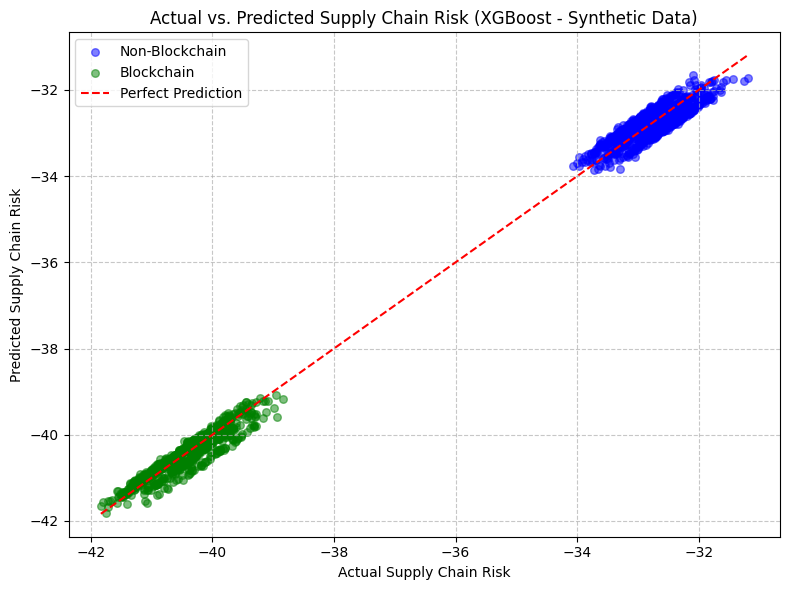

In [4]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs. predicted Supply Chain Risk (XGBoost, Synthetic Data)
plt.figure(figsize=(8, 6))

# Plot for Non-Blockchain
plt.scatter(y_test_no_bc, xgb_y_pred_no_bc, alpha=0.5, color='blue', label='Non-Blockchain', s=30)

# Plot for Blockchain
plt.scatter(y_test_with_bc, xgb_y_pred_with_bc, alpha=0.5, color='green', label='Blockchain', s=30)

# Add diagonal line for perfect prediction
min_val = min(y_test_no_bc.min(), y_test_with_bc.min(), xgb_y_pred_no_bc.min(), xgb_y_pred_with_bc.min())
max_val = max(y_test_no_bc.max(), y_test_with_bc.max(), xgb_y_pred_no_bc.max(), xgb_y_pred_with_bc.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Customize the chart
plt.xlabel('Actual Supply Chain Risk')
plt.ylabel('Predicted Supply Chain Risk')
plt.title('Actual vs. Predicted Supply Chain Risk (XGBoost - Synthetic Data)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


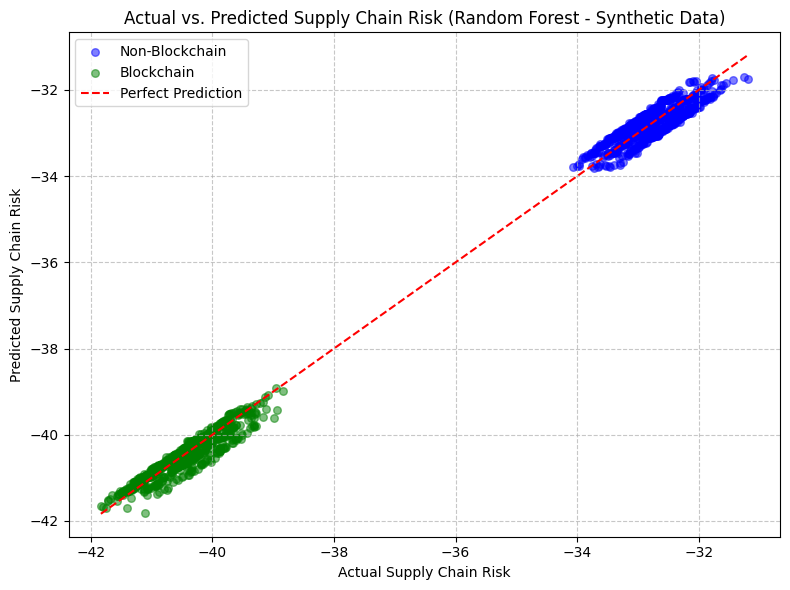

In [5]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs. predicted Supply Chain Risk (Random Forest, Synthetic Data)
plt.figure(figsize=(8, 6))

# Plot for Non-Blockchain
plt.scatter(y_test_no_bc, rf_y_pred_no_bc, alpha=0.5, color='blue', label='Non-Blockchain', s=30)

# Plot for Blockchain
plt.scatter(y_test_with_bc, rf_y_pred_with_bc, alpha=0.5, color='green', label='Blockchain', s=30)

# Add diagonal line for perfect prediction
min_val = min(y_test_no_bc.min(), y_test_with_bc.min(), rf_y_pred_no_bc.min(), rf_y_pred_with_bc.min())
max_val = max(y_test_no_bc.max(), y_test_with_bc.max(), rf_y_pred_no_bc.max(), rf_y_pred_with_bc.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Customize the chart
plt.xlabel('Actual Supply Chain Risk')
plt.ylabel('Predicted Supply Chain Risk')
plt.title('Actual vs. Predicted Supply Chain Risk (Random Forest - Synthetic Data)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\prady\AppData\Local\Temp\ipykernel_27240\533236936.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True,


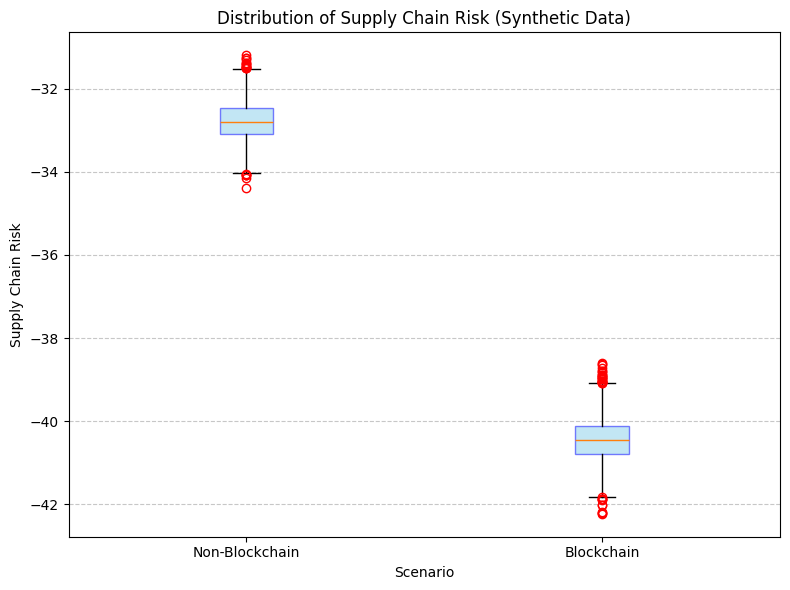

In [6]:
import matplotlib.pyplot as plt

# Box plot for Supply Chain Risk distribution (Synthetic Data)
plt.figure(figsize=(8, 6))

# Data for box plot
data = [y_no_bc, y_with_bc]
labels = ['Non-Blockchain', 'Blockchain']

# Create box plot
plt.boxplot(data, labels=labels, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='blue', alpha=0.5),
            flierprops=dict(color='red', markeredgecolor='red'))

# Customize the chart
plt.xlabel('Scenario')
plt.ylabel('Supply Chain Risk')
plt.title('Distribution of Supply Chain Risk (Synthetic Data)')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()


C:\Users\prady\AppData\Local\Temp\ipykernel_27240\654468431.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Scenario', y='Mitigation Power', data=data, palette=['blue', 'green', 'skyblue', 'limegreen'])


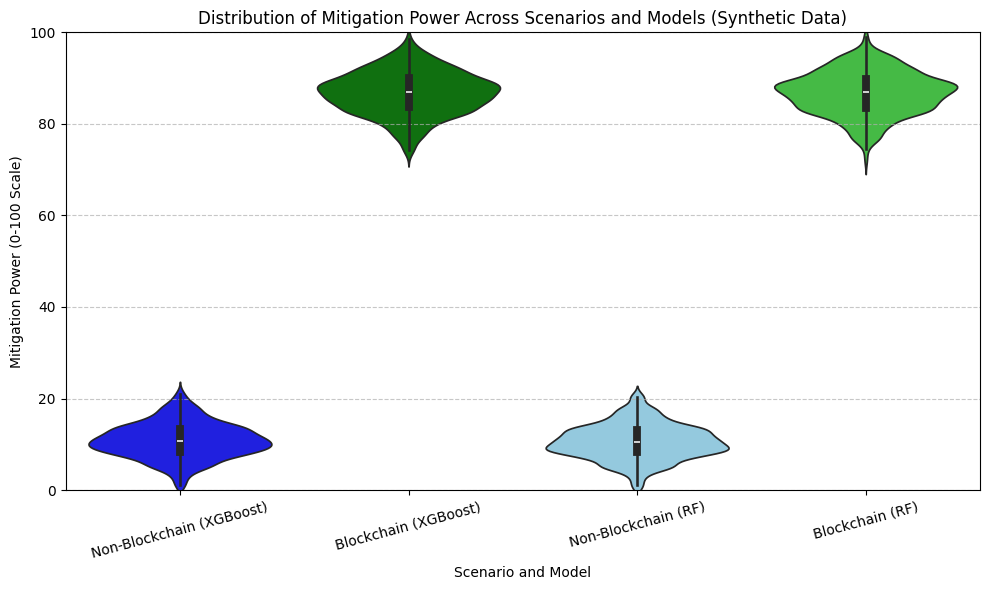

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for violin plot (Synthetic Data)
data = pd.DataFrame({
    'Scenario': ['Non-Blockchain (XGBoost)'] * len(xgb_mitigation_power_no_bc_normalized) + 
                ['Blockchain (XGBoost)'] * len(xgb_mitigation_power_with_bc_normalized) + 
                ['Non-Blockchain (RF)'] * len(rf_mitigation_power_no_bc_normalized) + 
                ['Blockchain (RF)'] * len(rf_mitigation_power_with_bc_normalized),
    'Mitigation Power': list(xgb_mitigation_power_no_bc_normalized) + 
                        list(xgb_mitigation_power_with_bc_normalized) + 
                        list(rf_mitigation_power_no_bc_normalized) + 
                        list(rf_mitigation_power_with_bc_normalized)
})

# Create violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Scenario', y='Mitigation Power', data=data, palette=['blue', 'green', 'skyblue', 'limegreen'])

# Customize the chart
plt.xlabel('Scenario and Model')
plt.ylabel('Mitigation Power (0-100 Scale)')
plt.title('Distribution of Mitigation Power Across Scenarios and Models (Synthetic Data)')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()
